In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from datetime import datetime
import os
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
import time

In [2]:
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

training_set = torchvision.datasets.CIFAR10('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.CIFAR10('./data', train=False, transform=transform, download=True)

training_loader = torch.utils.data.DataLoader(training_set, batch_size=64, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=64, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print('Training set has {} instances'.format(len(training_set)))
print('Validation set has {} instances'.format(len(validation_set)))

100.0%


Training set has 50000 instances
Validation set has 10000 instances


bird  car  ship  car


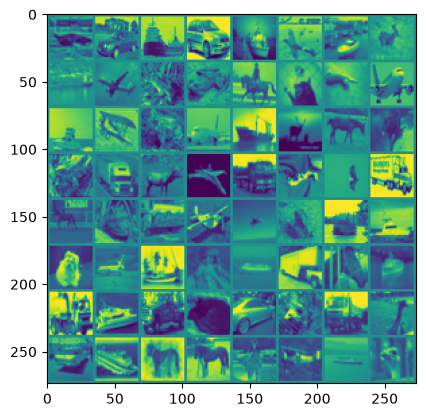

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg)
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)

img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)
print('  '.join(classes[labels[j]] for j in range(4)))

In [4]:
def plot_graph(history):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_figwidth(10)
    fig.suptitle("Train vs Validation")
    ax1.plot(history["train_acc"], label="Train")
    ax1.plot(history["validate_acc"], label="Validation")
    ax1.legend()
    ax1.set_title("Accuracy")

    ax2.plot(history["train_loss"], label="Train")
    ax2.plot(history["validate_loss"], label="Validation")
    ax2.legend()
    ax2.set_title("Loss")
    fig.show()

In [6]:
class ANN(nn.Module):
	def __init__(self):
		super(ANN, self).__init__()
		# DIY: Design Layers -----------------------------------------
		self.flatten = nn.Flatten()
		self.fc1 = nn.Linear(3 * 32 * 32, 1024)
		self.bn1 = nn.BatchNorm1d(1024)
		self.dropout1 = nn.Dropout(0.3)
		self.fc2 = nn.Linear(1024, 512)
		self.bn2 = nn.BatchNorm1d(512)
		self.dropout2 = nn.Dropout(0.3)
		self.fc3 = nn.Linear(512, 256)
		self.bn3 = nn.BatchNorm1d(256)
		self.dropout3 = nn.Dropout(0.2)
		self.fc4 = nn.Linear(256, 10)
		# DIY: Design Layers -----------------------------------------

	def forward(self, x):
		# DIY: Forward Pass  -----------------------------------------
		x = self.flatten(x)
		x = self.dropout1(F.relu(self.bn1(self.fc1(x))))
		x = self.dropout2(F.relu(self.bn2(self.fc2(x))))
		x = self.dropout3(F.relu(self.bn3(self.fc3(x))))
		x = self.fc4(x)
		# DIY: Forward Pass  -----------------------------------------
		return x


model = ANN()
summary(model, (3, 32, 32))


# DIY: Hyperparameters  -----------------------------------------
# Loss function
loss_fn = nn.CrossEntropyLoss()
# Optimiter
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# DIY: Hyperparameters  -----------------------------------------


epoch_number = 0

EPOCHS = 20
path_save_cp = './cp/'
best_vloss = 1_000_000.
training_logs = {"train_loss": [],  "train_acc": [], "validate_loss": [], "validate_acc": []}

t_0 = time.time()
for epoch in range(EPOCHS):
	train_loss, train_correct = 0, 0
	model.train(True)
	for i, data in enumerate(training_loader):
		inputs, labels = data

		# DIY: Training Loop  -----------------------------------------
		optimizer.zero_grad()
		outputs = model(inputs)
		loss = loss_fn(outputs, labels)
		loss.backward()
		optimizer.step()
		# DIY: Training Loop  -----------------------------------------


		train_loss += loss.item()
		train_correct += (outputs.argmax(1) == labels).float().sum().item()

	training_logs["train_loss"].append(train_loss / len(training_loader))
	training_logs["train_acc"].append(train_correct / len(training_loader.dataset))

	running_vloss = 0.0
	model.eval()
	valid_loss, valid_correct = 0, 0
	with torch.no_grad():
		for i, vdata in enumerate(validation_loader):
			vinputs, vlabels = vdata
			voutputs = model(vinputs)
			vloss = loss_fn(voutputs, vlabels)
			valid_loss += loss_fn(voutputs, vlabels).item()
			valid_correct += (voutputs.argmax(1) == vlabels).float().sum().item()
		# save validation logs
		training_logs["validate_loss"].append(valid_loss / len(validation_loader))
		training_logs["validate_acc"].append(valid_correct / len(validation_loader.dataset))

	if epoch % 1 == 0:
		print(f"Epochs {epoch+1}".ljust(10),
			f"train loss {training_logs['train_loss'][-1]:.5f}",
			f"train acc {training_logs['train_acc'][-1]:.5f}",

			f"validate loss {training_logs['validate_loss'][-1]:.5f}",
			f"validate acc {training_logs['validate_acc'][-1]:.5f}",
			)
		print("-"*80)

	if valid_loss < best_vloss:
		best_vloss = valid_loss
		if not os.path.exists(path_save_cp): os.mkdir(path_save_cp)
		torch.save(model.state_dict(), path_save_cp+'best_model.pth')

	epoch_number += 1

t_end = time.time()-t_0
print(f"Time consumption for non-accelerated CUDA training (CPU only): {t_end} sec")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                 [-1, 1024]       3,146,752
       BatchNorm1d-3                 [-1, 1024]           2,048
           Dropout-4                 [-1, 1024]               0
            Linear-5                  [-1, 512]         524,800
       BatchNorm1d-6                  [-1, 512]           1,024
           Dropout-7                  [-1, 512]               0
            Linear-8                  [-1, 256]         131,328
       BatchNorm1d-9                  [-1, 256]             512
          Dropout-10                  [-1, 256]               0
           Linear-11                   [-1, 10]           2,570
Total params: 3,809,034
Trainable params: 3,809,034
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forw

In [8]:
class CNN(nn.Module):
	def __init__(self):
		super(CNN, self).__init__()
		# DIY: Design Layers -----------------------------------------
		self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1) # 32x32 -> pool -> 16x16
		self.bn1 = nn.BatchNorm2d(16)
		self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # 16x16 -> pool -> 8x8
		self.bn2 = nn.BatchNorm2d(32)
		self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 8x8 -> pool -> 4x4
		self.bn3 = nn.BatchNorm2d(64)
		self.pool = nn.MaxPool2d(2)
		self.flatten = nn.Flatten()
		self.dropout = nn.Dropout(0.3)
		self.fc1 = nn.Linear(64 * 4 * 4, 128)
		self.fc2 = nn.Linear(128, 10)
		# DIY: Design Layers -----------------------------------------

	def forward(self, x):
		# DIY: Forward Pass  -----------------------------------------
		x = self.pool(F.relu(self.bn1(self.conv1(x))))
		x = self.pool(F.relu(self.bn2(self.conv2(x))))
		x = self.pool(F.relu(self.bn3(self.conv3(x))))
		x = self.flatten(x)
		x = self.dropout(F.relu(self.fc1(x)))
		x = self.fc2(x)
		# DIY: Forward Pass  -----------------------------------------
		return x


model = CNN()
summary(model, (3, 32, 32))


# DIY: Hyperparameters  -----------------------------------------
# Loss function
loss_fn = nn.CrossEntropyLoss()
# Optimiter
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# DIY: Hyperparameters  -----------------------------------------


epoch_number = 0

EPOCHS = 20
path_save_cp = './cp/'
best_vloss = 1_000_000.
training_logs = {"train_loss": [],  "train_acc": [], "validate_loss": [], "validate_acc": []}

t_0 = time.time()
for epoch in range(EPOCHS):
	train_loss, train_correct = 0, 0
	model.train(True)
	for i, data in enumerate(training_loader):
		inputs, labels = data

		# DIY: Training Loop  -----------------------------------------
		optimizer.zero_grad()
		outputs = model(inputs)
		loss = loss_fn(outputs, labels)
		loss.backward()
		optimizer.step()
		# DIY: Training Loop  -----------------------------------------


		train_loss += loss.item()
		train_correct += (outputs.argmax(1) == labels).float().sum().item()

	training_logs["train_loss"].append(train_loss / len(training_loader))
	training_logs["train_acc"].append(train_correct / len(training_loader.dataset))

	running_vloss = 0.0
	model.eval()
	valid_loss, valid_correct = 0, 0
	with torch.no_grad():
		for i, vdata in enumerate(validation_loader):
			vinputs, vlabels = vdata
			voutputs = model(vinputs)
			vloss = loss_fn(voutputs, vlabels)
			valid_loss += loss_fn(voutputs, vlabels).item()
			valid_correct += (voutputs.argmax(1) == vlabels).float().sum().item()
		# save validation logs
		training_logs["validate_loss"].append(valid_loss / len(validation_loader))
		training_logs["validate_acc"].append(valid_correct / len(validation_loader.dataset))

	if epoch % 1 == 0:
		print(f"Epochs {epoch+1}".ljust(10),
			f"train loss {training_logs['train_loss'][-1]:.5f}",
			f"train acc {training_logs['train_acc'][-1]:.5f}",

			f"validate loss {training_logs['validate_loss'][-1]:.5f}",
			f"validate acc {training_logs['validate_acc'][-1]:.5f}",
			)
		print("-"*80)

	if valid_loss < best_vloss:
		best_vloss = valid_loss
		if not os.path.exists(path_save_cp): os.mkdir(path_save_cp)
		torch.save(model.state_dict(), path_save_cp+'best_model.pth')

	epoch_number += 1

t_end = time.time()-t_0
print(f"Time consumption for non-accelerated CUDA training (CPU only): {t_end} sec")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             448
       BatchNorm2d-2           [-1, 16, 32, 32]              32
         MaxPool2d-3           [-1, 16, 16, 16]               0
            Conv2d-4           [-1, 32, 16, 16]           4,640
       BatchNorm2d-5           [-1, 32, 16, 16]              64
         MaxPool2d-6             [-1, 32, 8, 8]               0
            Conv2d-7             [-1, 64, 8, 8]          18,496
       BatchNorm2d-8             [-1, 64, 8, 8]             128
         MaxPool2d-9             [-1, 64, 4, 4]               0
          Flatten-10                 [-1, 1024]               0
           Linear-11                  [-1, 128]         131,200
          Dropout-12                  [-1, 128]               0
           Linear-13                   [-1, 10]           1,290
Total params: 156,298
Trainable params:

# Homework
ให้เติมโค้ดในส่วนที่กำหนดเพื่อให้สามารถรันโค้ดได้ตามปกติ
```
# DIY: A  -----------------------------------------
 < ----- ให้เขียนโค้ดในช่วงนี้
 < ----- ให้เขียนโค้ดในช่วงนี้
 < ----- ให้เขียนโค้ดในช่วงนี้
# DIY: A  -----------------------------------------
```

กำหนดให้ใช้ CIFAR 10 Dataset ที่จำแนกคลาสทั้งหมด 10 คลาสตามตัวอย่างภาพข้างใต้

1.
- ออกแบบและสร้างเพียงโมเดล ANN ที่สามารถทำให้ความแม่นยำ Accuracy ≥ 50% (Hint: Flatten ตั้งแต่ input)
- เมื่อทำเสร็จแล้ว ให้ แคปภาพค่า Loss และ Accuracy ระหว่างการ Train
- บันทึกเป็นไฟล์ PDF และแนบมาพร้อมกับ ภาพแคป Layers ทั้งหมดของโมเดลที่ใช้
2.
- ออกแบบและสร้าง โมเดล CNN ที่สามารถทำให้ความแม่นยำ Accuracy ≥ ANN model accuracy
- เมื่อทำเสร็จแล้ว ให้ แคปภาพค่า Loss และ Accuracy ระหว่างการ Train
- บันทึกเป็นไฟล์ PDF และแนบมาพร้อมกับ ภาพแคป Layers ทั้งหมดของโมเดลที่ใช้



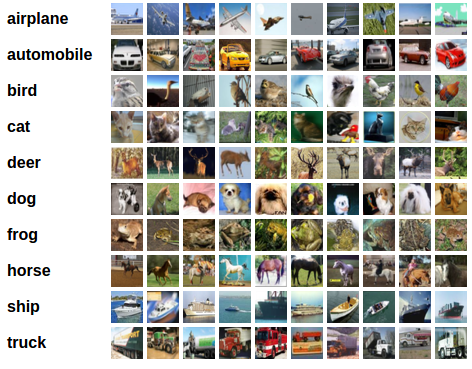